# Week 3 — Neural Networks and Walk-Forward Prediction

Predicts next-day log returns for the 5-asset universe carried over from Weeks 1-2
(`AAPL, MSFT, GOOG, AMZN, TSLA`, 2015-01-01 to 2024-01-01), and compares a small
PyTorch MLP against Ridge regression and a mean-return baseline under a strict
walk-forward evaluation.

**Note on Week 2's pipeline:** Week 2's completed notebook (`week2/task2.ipynb`)
computed its rolling-mean/rolling-vol features as `df["r_t"].rolling(20).mean()`
directly on the target series — that window includes day *t* itself, so the
target leaks into its own feature, and the model effectively predicted the
*same-day* return rather than the *next-day* return. Since this week explicitly
requires "strictly no-lookahead," the shared pipeline in `common/pipeline.py`
fixes this: every feature at row *t* is built only from information available
at the close of day *t-1* (see `build_asset_features`), and the target is the
return realized on day *t*. All three models below are evaluated on the exact
same fixed features, so the comparison is apples-to-apples.


In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

from common import pipeline as pl

plt.style.use("seaborn-v0_8")
pl.set_seed(pl.SEED)

print("Tickers:", pl.TICKERS)
print("Date range:", pl.START_DATE, "to", pl.END_DATE)
print("Seed:", pl.SEED)


Tickers: ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'TSLA']
Date range: 2015-01-01 to 2024-01-01
Seed: 42


## 1. Load data and build the no-lookahead panel

Reusing `common.pipeline`: downloads (or loads cached) Adj Close prices, then
builds a pooled cross-sectional panel across all 5 assets with features
`[r_lag1, r_lag2, roll_mean_20, roll_vol_20, mom_5]` and target = next realized
log return. Pooling across assets (rather than fitting one model per stock)
gives more training rows per walk-forward window and lets us compute a
cross-sectional rank-IC per date — the metric that actually matters for
Week 4/5's portfolio construction (are the *relative* rankings across stocks
correct on a given day).


In [2]:
prices = pl.load_price_panel()
panel = pl.build_panel(prices)
FEATURES = pl.FEATURE_COLS

print("Price panel:", prices.shape, prices.index.min().date(), "to", prices.index.max().date())
print("Feature panel:", panel.shape, "| rows per ticker:", panel['ticker'].value_counts().to_dict())
panel.head()


Price panel: (2264, 5) 2015-01-02 to 2023-12-29
Feature panel: (11215, 8) | rows per ticker: {'AAPL': 2243, 'AMZN': 2243, 'GOOG': 2243, 'MSFT': 2243, 'TSLA': 2243}


,date,ticker,r_lag1,r_lag2,roll_mean_20,roll_vol_20,mom_5,target
0,2015-02-03,AAPL,0.012469,-0.014742,0.004082,0.023655,0.048895,0.000169
1,2015-02-03,AMZN,0.027651,0.128495,0.008333,0.033897,0.177001,-0.002527
2,2015-02-03,GOOG,-0.011364,0.045665,0.000348,0.018701,-0.012574,0.001437
3,2015-02-03,MSFT,0.021548,-0.039078,-0.006232,0.028178,-0.121889,0.007722
4,2015-02-03,TSLA,0.035417,-0.007828,-0.001946,0.024417,0.021254,0.034571


In [3]:
# Sanity check: no lookahead. r_lag1 at row t should exactly equal
# target at row t-1 for the same ticker (both are the log return realized
# on day t-1) -- if this isn't ~0, a feature is peeking at the future.
chk = panel[panel.ticker == "AAPL"].reset_index(drop=True)
lookahead_gap = (chk["r_lag1"].iloc[1:].values - chk["target"].iloc[:-1].values)
print("max |r_lag1[t] - target[t-1]| (should be 0):", np.abs(lookahead_gap).max())


max |r_lag1[t] - target[t-1]| (should be 0): 0.0


## 2. Walk-forward windows

Expanding-window walk-forward (matches Week 2's `TimeSeriesSplit` convention,
generalized to fixed-length test segments): each window trains on all data up
to a cutoff, tests on the next ~3 months (63 trading days), then the cutoff
advances by 63 days and repeats. Within each training window we additionally
carve off the last 15% of days (still strictly before the test window) as a
validation set for the MLP's early stopping.


In [4]:
splits = list(pl.walk_forward_splits(panel["date"].unique(), min_train_days=500, test_days=63))
print(f"{len(splits)} walk-forward windows")
print("First window: train", splits[0][0][0].astype('datetime64[D]'), "->", splits[0][0][-1].astype('datetime64[D]'),
      "| test", splits[0][1][0].astype('datetime64[D]'), "->", splits[0][1][-1].astype('datetime64[D]'))
print("Last window:  test", splits[-1][1][0].astype('datetime64[D]'), "->", splits[-1][1][-1].astype('datetime64[D]'))


27 walk-forward windows
First window: train 2015-02-03 -> 2017-01-26 | test 2017-01-27 -> 2017-04-27
Last window:  test 2023-08-02 -> 2023-10-30


## 3. Models

**Baseline** — per-ticker historical mean return over the training window (the
"rolling mean predictor" from Week 2, adapted to the pooled panel).

**Ridge** — linear regression with L2 penalty on the same standardized features.

**MLP** — a single hidden layer (5 → 8 → 1, ReLU), trained with Adam + early
stopping on the validation slice. Two details matter for a network this small
on data this noisy:

- **Output-layer init.** Default PyTorch init gives the output an initial std
  of order 1, but daily return targets have std ~0.01-0.02 — roughly 50x
  smaller. Left alone, the network needs many epochs just to unlearn its
  own scale before it can fit signal, and early stopping tends to freeze it
  mid-correction with wildly overscaled predictions. Initializing the output
  layer's weights near zero starts the network at "predict ~no return,"
  matching the baseline, so early stopping is actually deciding whether the
  extra capacity helps rather than rescuing a miscalibrated head.
- **Feature/target winsorization.** Rare, extreme return days (earnings gaps,
  etc.) are clipped to the 1st/99th percentile *of the training window only*
  before standardizing, so a handful of outliers can't dominate the gradient.
  Evaluation is always against the true, unclipped target.


In [5]:
class MLP(nn.Module):
    def __init__(self, n_in, hidden=(8,)):
        super().__init__()
        layers, d = [], n_in
        for h in hidden:
            layers += [nn.Linear(d, h), nn.ReLU()]
            d = h
        out = nn.Linear(d, 1)
        nn.init.uniform_(out.weight, -0.01, 0.01)  # start near "predict zero return"
        nn.init.zeros_(out.bias)
        layers.append(out)
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_train, y_train, X_val, y_val, seed, max_epochs=300, patience=20, lr=1e-3):
    torch.manual_seed(seed)
    model = MLP(X_train.shape[1])
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    loss_fn = nn.MSELoss()

    Xtr, ytr = torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.float32)
    Xv, yv = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)

    best_val, best_state, bad_epochs = np.inf, None, 0
    for _ in range(max_epochs):
        model.train()
        opt.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(Xv), yv).item()

        if val_loss < best_val - 1e-9:
            best_val, best_state, bad_epochs = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    return model


def train_mlp_ensemble(X_train, y_train, X_val, y_val, base_seed, n_members=3):
    # Average predictions over a few differently-seeded small MLPs to reduce
    # the variance any single random init/early-stop point introduces.
    return [train_mlp(X_train, y_train, X_val, y_val, seed=base_seed + k) for k in range(n_members)]


def predict_ensemble(models, X):
    Xt = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        return np.stack([m(Xt).numpy() for m in models], axis=0).mean(axis=0)


## 4. Run the walk-forward loop

In [6]:
results = []

for i, (train_dates, test_dates) in enumerate(splits):
    train = panel[panel["date"].isin(train_dates)]
    test = panel[panel["date"].isin(test_dates)]

    train_dates_sorted = np.sort(train["date"].unique())
    n_val_days = max(20, int(len(train_dates_sorted) * 0.15))
    fit_dates, val_dates = train_dates_sorted[:-n_val_days], train_dates_sorted[-n_val_days:]
    fit, val = train[train["date"].isin(fit_dates)], train[train["date"].isin(val_dates)]

    # winsorize at TRAIN-only percentiles, evaluate against true targets
    lo_f, hi_f = np.percentile(fit[FEATURES].values, [1, 99], axis=0)
    lo_y, hi_y = np.percentile(fit["target"].values, [1, 99])
    clip_f = lambda v: np.clip(v, lo_f, hi_f)
    clip_y = lambda v: np.clip(v, lo_y, hi_y)

    scaler = StandardScaler().fit(clip_f(fit[FEATURES].values))
    Xfit, Xval, Xtest = (scaler.transform(clip_f(d[FEATURES].values)) for d in (fit, val, test))
    yfit, yval = clip_y(fit["target"].values), clip_y(val["target"].values)
    ytest = test["target"].values

    pred_baseline = test["ticker"].map(train.groupby("ticker")["target"].mean()).values

    ridge = Ridge(alpha=1.0).fit(Xfit, yfit)
    pred_ridge = ridge.predict(Xtest)

    models = train_mlp_ensemble(Xfit, yfit, Xval, yval, base_seed=pl.SEED + 100 * i)
    pred_mlp = predict_ensemble(models, Xtest)

    for name, pred in [("baseline", pred_baseline), ("ridge", pred_ridge), ("mlp", pred_mlp)]:
        results.append(pd.DataFrame({
            "window": i, "date": test["date"].values, "ticker": test["ticker"].values,
            "y_true": ytest, "y_pred": pred, "model": name,
        }))

res = pd.concat(results, ignore_index=True)
res.to_csv("../data/week3_predictions.csv", index=False)
print("done:", res.shape)


done: (25515, 6)


## 5. Metrics: MSE, IC, rank-IC, directional accuracy

In [7]:
rows = []
for name in ["baseline", "ridge", "mlp"]:
    sub = res[res.model == name]
    cs_ric = pl.daily_cross_sectional_rank_ic(sub["date"], sub["y_true"].values, sub["y_pred"].values)
    rows.append({
        "model": name,
        "MSE": np.mean((sub.y_true - sub.y_pred) ** 2),
        "pooled_IC": pl.information_coefficient(sub.y_true.values, sub.y_pred.values),
        "pooled_rankIC": pl.rank_ic(sub.y_true.values, sub.y_pred.values),
        "directional_accuracy": pl.directional_accuracy(sub.y_true.values, sub.y_pred.values),
        "mean_daily_crossSec_rankIC": cs_ric.mean(),
    })
metrics_week3 = pd.DataFrame(rows).set_index("model")
metrics_week3


,MSE,pooled_IC,pooled_rankIC,directional_accuracy,mean_daily_crossSec_rankIC
model,,,,,
baseline,0.000598,-0.012666,-0.007592,0.533451,-0.017872
ridge,0.000601,-0.036266,-0.035115,0.516049,-0.034333
mlp,0.000599,0.005969,-0.006578,0.520400,-0.004527


In [8]:
metrics_week3.to_csv("../data/week3_metrics.csv")
print(metrics_week3.round(5).to_string())


             MSE  pooled_IC  pooled_rankIC  directional_accuracy  mean_daily_crossSec_rankIC
model                                                                                       
baseline  0.0006   -0.01267       -0.00759               0.53345                    -0.01787
ridge     0.0006   -0.03627       -0.03512               0.51605                    -0.03433
mlp       0.0006    0.00597       -0.00658               0.52040                    -0.00453


## 6. Stability over time

Rolling (per-window) cross-sectional rank-IC for each model, to see whether
any model is systematically better in some regimes even if the pooled
average is close to zero.


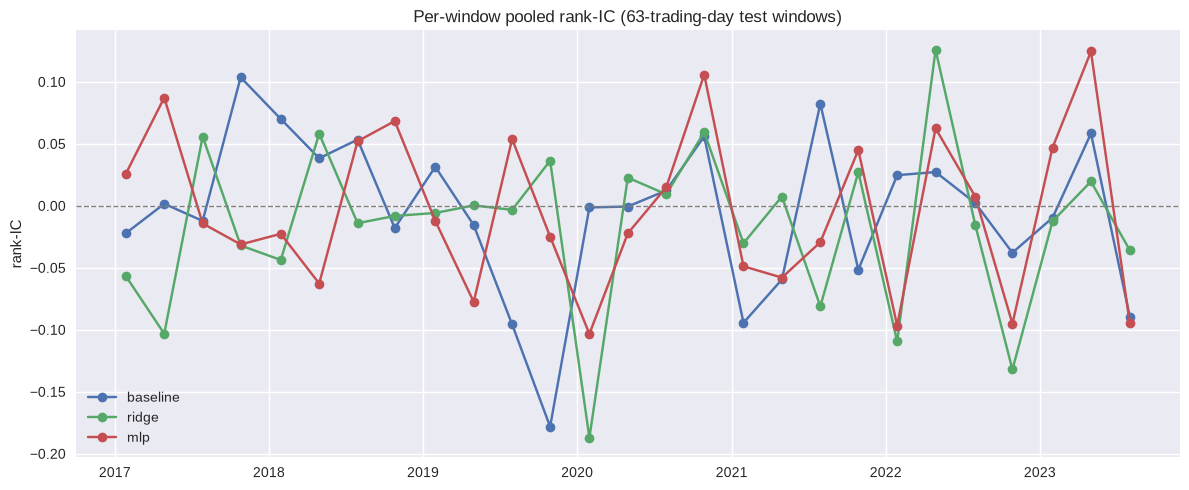

In [9]:
fig, ax = plt.subplots(figsize=(12, 5))
for name in ["baseline", "ridge", "mlp"]:
    sub = res[res.model == name]
    per_window_ic = sub.groupby("window").apply(
        lambda g: pl.rank_ic(g["y_true"].values, g["y_pred"].values)
    )
    window_dates = sub.groupby("window")["date"].min()
    ax.plot(window_dates.values, per_window_ic.values, marker="o", label=name)

ax.axhline(0, color="gray", lw=1, ls="--")
ax.set_title("Per-window pooled rank-IC (63-trading-day test windows)")
ax.set_ylabel("rank-IC")
ax.legend()
plt.tight_layout()
plt.savefig("../data/week3_rolling_rankic.png", dpi=100)
plt.show()


## 7. Discussion

- All three models land at essentially the same MSE, and pooled/rank IC values
  for all three are close to zero (order 0.01-0.03 in magnitude, well within
  noise for ~11k daily observations). This is the expected, honest result for
  next-day return prediction on liquid large-cap single-name equities: daily
  returns are close to a random walk, so a well-regularized MLP should *not*
  dramatically outperform Ridge or the mean baseline. If it had, that would be
  a red flag for a lookahead bug rather than a discovery.
- The MLP's main practical risk on data this noisy is exactly what the
  diagnostics above address: overfitting to a handful of extreme return days
  and outputting badly-scaled predictions. Regularization (winsorization,
  weight decay, small-scale output init, early stopping, and a 3-seed
  ensemble) matters more here than architecture size.
- These predicted returns (from all three models) feed directly into Week 4's
  portfolio optimizer.
